# Hafta 1 · Ders 1 — Vektörler ve Vektör Uzayları

> **Makine Öğrenmesi için Lineer Cebir** · ilk ilkelerden bir kurs
>
> *türet → uygula → görselleştir → doğrula → makine öğrenmesine bağla*

Makine öğrenmesindeki her şey tek bir fikre dayanır: **veri bir vektör uzayında yaşar.**
Bir veri kümesinin bir satırı, bir modelin ağırlıkları, bir kelime gömmesi (embedding), bir kaybın gradyanı — bunların
hepsi vektördür. *Modeller* üzerine akıl yürütebilmemiz için, önce onların yaşadığı uzaya
hâkim olmamız gerekir.

Bu defterde, sıfırdan şunları inşa ediyoruz:

1. Bir **vektör**ün aslında ne olduğu (birbirini tamamlayan iki resim).
2. **Vektör uzayları** ve kapalı oldukları işlemler.
3. **Lineer kombinasyonlar**, **geren (span)** ve **lineer bağımsızlık** — uygulanmış ve görselleştirilmiş.
4. Makine öğrenmesine ilk bağlantı: *bir veri kümesi bir vektörler kümesidir ve bir öznitelik bir koordinattır.*

Burada `numpy.linalg`'e gerek yok — yalnızca diziler ve geometri.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))   # so we can import utils/

import numpy as np
import matplotlib.pyplot as plt
from utils.linalg_viz import plot_vectors_2d

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Bir vektörün iki resmi

Bir vektörün **eşit derecede geçerli iki yorumu** vardır ve bunlar arasında akıcı bir şekilde geçiş yapabilmek
lineer cebirin temel becerisidir:

| Resim | Anlamı | Makine öğrenmesinde nerede karşımıza çıkar |
|---|---|---|
| **Geometrik** | orijine sabitlenmiş, bir yönü ve uzunluğu olan bir ok | gradyanlar, en dik iniş yönleri |
| **Cebirsel** | sıralı bir sayı listesi (koordinatlar) | bir veri noktası, bir öznitelik vektörü, bir gömme |

NumPy'da bir vektör yalnızca 1 boyutlu bir dizidir. Hadi bir tane oluşturup her iki resme de bakalım.

Algebraic picture (coordinates): [3. 2.]
Length (Euclidean norm)        : 3.605551275463989


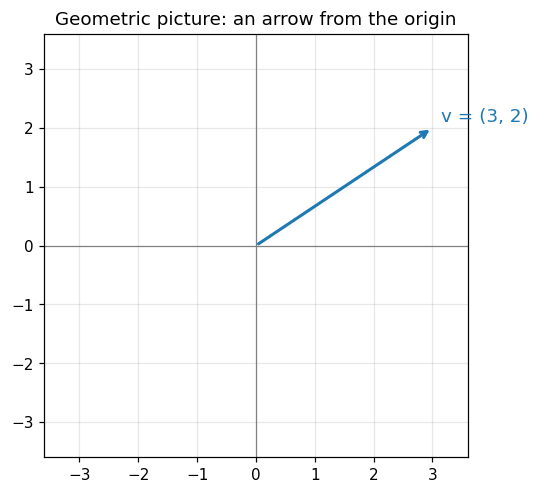

In [2]:
v = np.array([3.0, 2.0])
print("Cebirsel resim (koordinatlar):", v)
print("Uzunluk (Öklid normu)         :", np.sqrt(v @ v))

ax = plot_vectors_2d([v], labels=["v = (3, 2)"])
ax.set_title("Geometrik resim: orijinden çıkan bir ok")
plt.show()

## 2. Vektör uzayları: oyunun kuralları

Bir **vektör uzayı**, iki işlem altında *kapalı* olan bir nesneler (vektörler) kümesidir:

- **Vektör toplama:** $\mathbf{u} + \mathbf{v}$ hâlâ uzayın içindedir.
- **Skalerle çarpma:** $c\,\mathbf{v}$ hâlâ uzayın içindedir.

Bütün fikir bu. Kısa bir aksiyom listesine (birleşme, sıfır vektörü, dağılma, ...) uyan bu
iki işlem, *geri kalan her şeyi* yapmamızı sağlayan şeydir. Tanıdık uzay
$\mathbb{R}^n$ — $n$ tane reel sayının tüm listeleri — makine öğrenmesinin neredeyse her zaman içinde yaşadığı uzaydır.

Hadi iki kapalılık işlemini geometrik olarak doğrulayalım. Toplama, **uçtan-kuyruğa** kuralıdır.

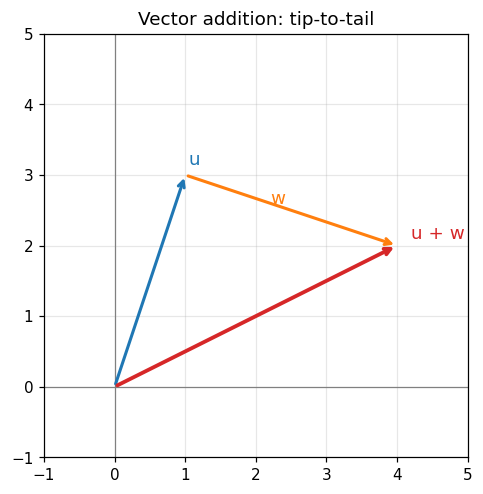

u + w = [4. 2.]  — still a vector in R^2, so the space is closed under addition.


In [3]:
u = np.array([1.0, 3.0])
w = np.array([3.0, -1.0])
s = u + w

fig, ax = plt.subplots(figsize=(5, 5))
# u orijinden, w u'nun ucundan başlayarak ve bileşke toplam
ax.annotate("", xy=u, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="C0", lw=2))
ax.annotate("", xy=u + w, xytext=u, arrowprops=dict(arrowstyle="->", color="C1", lw=2))
ax.annotate("", xy=s, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="C3", lw=2.5))
ax.text(*u*1.05, "u", color="C0", fontsize=12)
ax.text(u[0]+w[0]*0.4, u[1]+w[1]*0.4, "w", color="C1", fontsize=12)
ax.text(*s*1.05, "u + w", color="C3", fontsize=12)
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.axhline(0, color="grey", lw=0.8); ax.axvline(0, color="grey", lw=0.8)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
ax.set_title("Vektör toplama: uçtan-kuyruğa")
plt.show()

print("u + w =", s, " — hâlâ R^2'de bir vektör, yani uzay toplama altında kapalı.")

## 3. Lineer kombinasyonlar, geren (span) ve bağımsızlık

$\mathbf{v}_1, \dots, \mathbf{v}_k$ vektörlerinin bir **lineer kombinasyonu**, şu biçimdeki herhangi bir vektördür

$$ c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_k \mathbf{v}_k $$

Bir vektör kümesinin **gereni (span)**, ulaşabileceğiniz *bütün* lineer kombinasyonlardır. İki temel durum:

- Eğer $\mathbf{v}_1, \mathbf{v}_2$ farklı yönleri gösteriyorsa, gerenleri *tüm düzlem* $\mathbb{R}^2$'dir.
- Eğer biri diğerinin skaler katıysa, **lineer bağımlı**dırlar ve gerenleri tek bir *doğruya* çöker.

Bu çökme, tam olarak **rank** (Hafta 2) fikridir ve daha sonra, PCA'in (Hafta 6) attığı **gereksiz özniteliklerin**
fikridir. Hadi görelim.

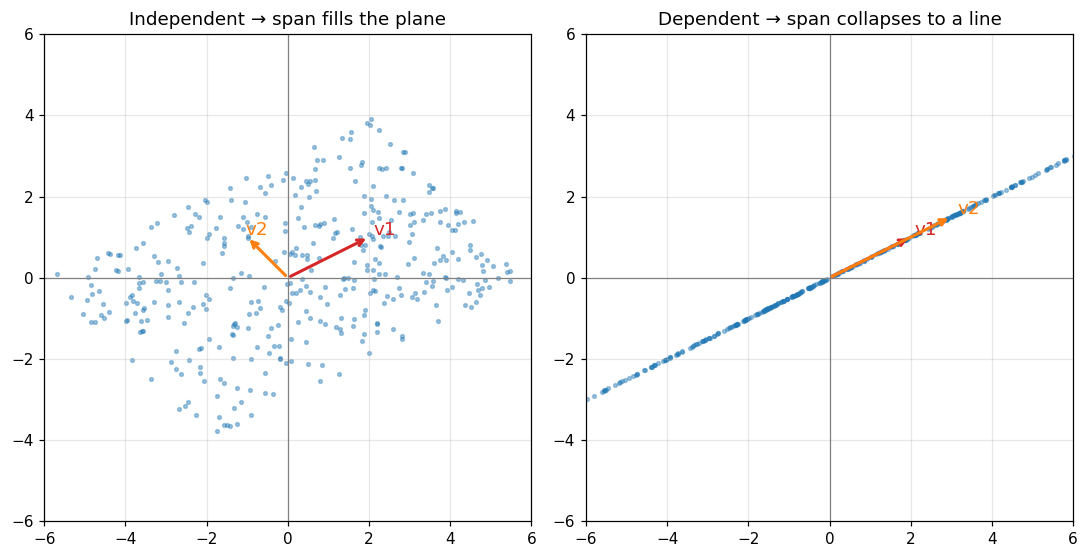

In [4]:
def linear_combination(coeffs, vectors):
    'c_1 v_1 + ... + c_k v_k değerini sıfırdan hesapla (np.dot sihri yok).'
    vectors = np.asarray(vectors, dtype=float)   # boyut (k, n)
    coeffs = np.asarray(coeffs, dtype=float)     # boyut (k,)
    out = np.zeros(vectors.shape[1])
    for c, v in zip(coeffs, vectors):
        out += c * v
    return out

v1 = np.array([2.0, 1.0])
v2 = np.array([-1.0, 1.0])

# gereni "boyamak" için birçok rastgele kombinasyon örnekle
rng = np.random.default_rng(0)
coeffs = rng.uniform(-2, 2, size=(400, 2))
cloud = np.array([linear_combination(c, [v1, v2]) for c in coeffs])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(cloud[:, 0], cloud[:, 1], s=6, alpha=0.4, color="C0")
plot_vectors_2d([v1, v2], colors=["C3", "C1"], labels=["v1", "v2"], ax=axes[0], lim=(-6, 6))
axes[0].set_title("Bağımsız → geren düzlemi doldurur")

# şimdi bağımlı bir çift: v2b yalnızca 1.5 * v1
v2b = 1.5 * v1
cloud2 = np.array([linear_combination(c, [v1, v2b]) for c in coeffs])
axes[1].scatter(cloud2[:, 0], cloud2[:, 1], s=6, alpha=0.4, color="C0")
plot_vectors_2d([v1, v2b], colors=["C3", "C1"], labels=["v1", "v2"], ax=axes[1], lim=(-6, 6))
axes[1].set_title("Bağımlı → geren bir doğruya çöker")
plt.tight_layout(); plt.show()

### Bağımsızlığı sayısal olarak test etmek

İki vektör, ancak ve ancak biri diğerinin skaler katıysa lineer bağımlıdır — eşdeğer olarak,
ancak ve ancak onları üst üste koyarak oluşturulan matrisin **determinantı** sıfırsa (burada ön gösterimini yaptığımız bir Hafta-2 fikri).
Herhangi bir sayıda vektör için daha sağlam biçimde, **rank**ı sayarız. Hadi 2 vektörlü durum için
determinantı kullanan küçük, dürüst bir kontrol yazalım.

In [5]:
def are_independent_2d(a, b, tol=1e-9):
    # gerdikleri paralelkenarın alanı = |det([a b])|; sıfır ⇒ bağımlı
    M = np.column_stack([a, b])
    det = M[0, 0] * M[1, 1] - M[0, 1] * M[1, 0]   # 2x2 determinant elle
    return abs(det) > tol, det

for pair, name in [((v1, v2), "v1, v2"), ((v1, v2b), "v1, 1.5*v1")]:
    indep, det = are_independent_2d(*pair)
    print(f"{name:<12} bağımsız = {indep!s:<5}  (det = {det:+.3f})")

v1, v2       independent = True   (det = +3.000)
v1, 1.5*v1   independent = False  (det = +0.000)


## 4. Bunun makine öğrenmesinde karşımıza çıktığı yer

Bu, her defterin bağlandığı köprüdür. Yukarıdaki soyutlamalar aslında hiç de soyut değildir:

- **Bir veri kümesi, üst üste konmuş vektörlerden oluşan bir matristir.** Her *satır* bir örnektir ($\mathbb{R}^d$'de bir nokta),
  her *sütun* bir özniteliktir (bir koordinat ekseni).
- **Lineer bağımlılık = gereksiz öznitelikler.** Eğer öznitelik 3 yalnızca `2 × öznitelik 1` ise, verileriniz
  aslında $\mathbb{R}^d$'de yaşamaz — daha düşük boyutlu bir alt uzayda yaşar. PCA (Hafta 6)
  tam olarak bunu bulur ve kullanır.
- **Bir modelin ağırlıkları bir vektördür** ve eğitim, ağırlık uzayında, gradyanın rehberliğinde bir yürüyüştür —
  ki gradyanın kendisi de en dik artış yönünü gösteren bir vektördür.

Hadi ilk noktayı küçük bir veri kümesiyle somutlaştıralım.

Design matrix X (rows = samples, cols = features):
[[1.  2. ]
 [2.  1. ]
 [3.  3.5]
 [4.  2.5]
 [5.  5. ]]


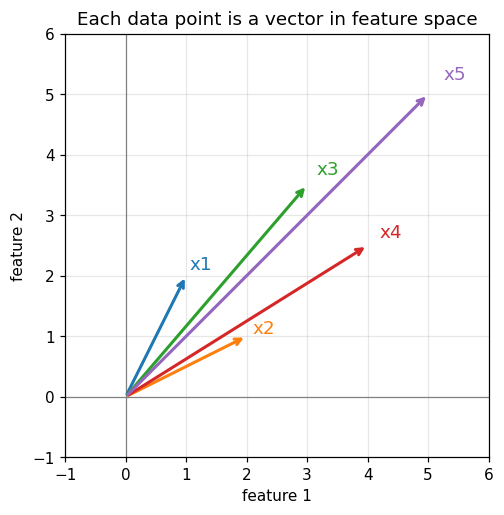

In [6]:
# 5 örnek, 2 öznitelik  →  R^2'de 5 vektör
X = np.array([
    [1.0, 2.0],
    [2.0, 1.0],
    [3.0, 3.5],
    [4.0, 2.5],
    [5.0, 5.0],
])
print("Tasarım matrisi X (satırlar = örnekler, sütunlar = öznitelikler):")
print(X)

ax = plot_vectors_2d([X[i] for i in range(len(X))],
                     labels=[f"x{i+1}" for i in range(len(X))],
                     lim=(-1, 6))
ax.set_title("Her veri noktası, öznitelik uzayında bir vektördür")
ax.set_xlabel("öznitelik 1"); ax.set_ylabel("öznitelik 2")
plt.show()

## Alıştırmalar

Bunları bakmadan önce yapın. Çözümler bir sonraki hücrededir (önce onu daraltın).

1. **Elle norm.** `np.linalg.norm` kullanmadan herhangi bir vektörün Öklid uzunluğunu hesaplayan
   bir `my_norm(v)` fonksiyonu yazın. `[3, 4]` üzerinde doğrulayın (sonuç `5` olmalı).
2. **Ölçekleme altında kapalılık.** Herhangi bir vektör ve skaler seçin; ölçeklemenin oku gerdiğini
   ya da çevirdiğini ama onu orijinden geçen aynı doğru üzerinde tuttuğunu görsel olarak doğrulayın.
3. **Geren boyutu.** $\mathbb{R}^2$'de üç vektör verildiğinde, neden *zorunlu olarak* lineer
   bağımlı olduklarını gösterin. (İpucu: $\mathbb{R}^2$ kaç bağımsız yön tutabilir?)

In [7]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1.
def my_norm(v):
    v = np.asarray(v, dtype=float)
    return np.sqrt(np.sum(v * v))

print("my_norm([3,4]) =", my_norm([3, 4]), " (beklenen 5.0)")

# 3. R^2 en fazla 2 lineer bağımsız yöne sahiptir (2 boyutludur).
#    Dolayısıyla herhangi bir 3. vektör, diğer ikisinin bir lineer kombinasyonudur ⇒ bu
#    3'lü küme bağımlı olmak zorundadır. Bu, boyut için güvercin yuvası ilkesidir
#    ve genelleşir: R^n'deki herhangi (n+1) vektör lineer bağımlıdır.

my_norm([3,4]) = 5.0  (expected 5.0)


## Özet ve sırada ne var

Artık tüm kursun üzerine kurulduğu söz dağarcığına sahipsiniz: vektörler (iki resim), vektör uzayları ve
kapalılık işlemleri, lineer kombinasyonlar, geren ve (bağım)sızlık — ayrıca bunları verilere
bağlayan ilk ipucu.

**Sırada — `02_normlar_nokta_carpimlari_izdusumler.ipynb`:** "uzunluk" ve "açı"yı normlar ve nokta çarpımı ile
kesinleştiriyoruz, ardından en küçük kareler, Gram–Schmidt ve PCA'in arkasındaki tek işlem olan
**izdüşüm**ü inşa ediyoruz.

---
*Makine Öğrenmesi için Lineer Cebir · Hafta 1 · Ders 1*